# TP2 Starter Pack: Image-to-Prompt Inversion

This notebook provides the basic utilities needed for TP2:

- mount Google Drive in Colab / VS Code Colab extension;
- load the TP2 target images;
- extract the fixed render seed from each target filename;
- load the LCM generator `SimianLuo/LCM_Dreamshaper_v7`;
- generate images from prompts using the same settings as the target images;
- save generated images and metadata.

The goal of TP2 is to find prompts that reproduce the target images as closely as possible when rendered with the same LCM setup.


## 1. Install Dependencies

Run this cell first in Colab. Ignore last errors.


In [21]:
# Install the PyTorch Diffusers stack.
# Pillow 12 can break some Diffusers/Transformers imports in Colab Python 3.12
# with errors such as: cannot import name '_Ink' from PIL._typing.
!pip install -q -U "diffusers[torch]" transformers accelerate safetensors matplotlib "pandas<3"
!pip install -q -U --force-reinstall "Pillow<12"

# for evaluating the similarity between generated and target images, we will use LPIPS and CLIP-based metrics.
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install lpips


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-hpgw8ib0
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-hpgw8ib0
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=9ad0e65ebcdb756864d92c64e03e9cb59381e33b51c71c702e9a0f28e2b4e6d1
  Stored in directory: /tmp/pip-ephem-wheel-cache-8x_t6aaa/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
  Using cached lpips-0.1.4-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.9 MB/s eta 0:00:00


## 2. Google Drive and Target Paths

The notebook avoids the Colab upload widget, which is unreliable in the VS Code Colab extension.

Recommended Drive layout:

```text
MyDrive/GENAI_TP2/tp2-chosen/*.png
```

Alternative: place `tp2-chosen.zip` in `MyDrive/GENAI_TP2/`.


In [3]:
# gestire percorsi dei file in modo indipendente dal sistema operativo
from pathlib import Path
# serve per estrarre cartelle zip
import zipfile
# utilizzata per scaricare file da internet
import urllib.request

MOUNT_GOOGLE_DRIVE = True

if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print("Google Drive mount skipped:", exc)

# Optional online URL for a zip with the target images.
# Leave empty if targets are already available locally or in Drive.
TARGETS_ZIP_URL = ""

CONTENT_DIR = Path("/content")
DRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_PROJECT_DIR = DRIVE_ROOT / "GENAI_TP2"
LOCAL_PROJECT_DIR = CONTENT_DIR / "GENAI_TP2" if CONTENT_DIR.exists() else Path("students")

if DRIVE_ROOT.exists():
    DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs"
elif CONTENT_DIR.exists():
    OUTPUT_DIR = CONTENT_DIR / "tp2_outputs"
else:
    OUTPUT_DIR = Path("students/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ricerca delle immagini 
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

# Funzione che scansiona cartelle e sottocartelle per trovare immagini con estensioni specifiche
def list_target_images(path):
    path = Path(path)
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path]
    if not path.exists():
        return []
    return sorted(p for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)

# DOVE CERCARE LE IMMAGINI: prima cartella trovata con immagini, altrimenti estrai il primo zip trovato
TARGET_DIR_CANDIDATES = [
    Path("students/tp2-chosen"),
    Path("tp2-chosen"),
    Path("/content/tp2-chosen"),
    Path("/content/tp2_targets"),
    DRIVE_PROJECT_DIR / "tp2-chosen",
    Path("/content/drive/MyDrive/tp2-chosen"),
    Path("/content/drive/MyDrive/tp2_targets"),
]

ZIP_CANDIDATES = [
    Path("students/tp2-chosen.zip"),
    Path("tp2-chosen.zip"),
    Path("/content/tp2-chosen.zip"),
    DRIVE_PROJECT_DIR / "tp2-chosen.zip",
    Path("/content/drive/MyDrive/tp2-chosen.zip"),
]

# Download optional online zip.
if TARGETS_ZIP_URL:
    LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_zip = LOCAL_PROJECT_DIR / "tp2-chosen.zip"
    urllib.request.urlretrieve(TARGETS_ZIP_URL, downloaded_zip)
    ZIP_CANDIDATES.insert(0, downloaded_zip)
    print("Downloaded targets zip to", downloaded_zip)

# Extract first available zip if no folder with images exists yet.
if not any(list_target_images(candidate) for candidate in TARGET_DIR_CANDIDATES):
    for zip_path in ZIP_CANDIDATES:
        if zip_path.exists():
            extract_dir = Path("/content/tp2-chosen") if CONTENT_DIR.exists() else Path("tp2-chosen")
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(extract_dir)
            print(f"Extracted {zip_path} -> {extract_dir}")
            break

TARGET_DIR = None
for candidate in TARGET_DIR_CANDIDATES:
    if list_target_images(candidate):
        TARGET_DIR = candidate
        break

if TARGET_DIR is None:
    raise FileNotFoundError(
        "No target images found. Put images in MyDrive/GENAI_TP2/tp2-chosen, "
        "or put tp2-chosen.zip in MyDrive/GENAI_TP2, or set TARGETS_ZIP_URL."
    )

target_images = list_target_images(TARGET_DIR)
print("Target folder:", TARGET_DIR)
print("Output folder:", OUTPUT_DIR)
print("Number of targets:", len(target_images))
target_images


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted /content/drive/MyDrive/GENAI_TP2/tp2-chosen.zip -> /content/tp2-chosen
Target folder: tp2-chosen
Output folder: /content/drive/MyDrive/GENAI_TP2/outputs
Number of targets: 6


[PosixPath('tp2-chosen/1159_25.png'),
 PosixPath('tp2-chosen/1159_29.png'),
 PosixPath('tp2-chosen/1159_3.png'),
 PosixPath('tp2-chosen/1159_7.png'),
 PosixPath('tp2-chosen/7836.png'),
 PosixPath('tp2-chosen/9338.png')]

## 3. Utilities: Seeds, Display, and Output Folders

The target filename encodes the render seed:

- `7836.png` uses seed `7836`;
- `1159_25.png` uses seed `1159`.


In [4]:
import csv
import json
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def seed_from_filename(path, fallback=2026):
    match = re.match(r"^(\d+)", Path(path).stem)
    return int(match.group(1)) if match else fallback


def safe_stem(path):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in Path(path).stem)


def load_image(path):
    return Image.open(path).convert("RGB")


def create_run_dir(base_dir=OUTPUT_DIR, identity="student_run"):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = Path(base_dir) / f"{timestamp}_{identity}"
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir


def write_csv(path, rows):
    rows = list(rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        Path(path).write_text("")
        return
    fieldnames = []
    for row in rows:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def show_images(paths, cols=3, title=None):
    paths = list(paths)
    if not paths:
        print("No images to show.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    for ax in [ax for row in axes for ax in row]:
        ax.axis("off")
    for ax, path in zip([ax for row in axes for ax in row], paths):
        ax.imshow(load_image(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for path in target_images:
    print(Path(path).name, "-> seed", seed_from_filename(path))


1159_25.png -> seed 1159
1159_29.png -> seed 1159
1159_3.png -> seed 1159
1159_7.png -> seed 1159
7836.png -> seed 7836
9338.png -> seed 9338


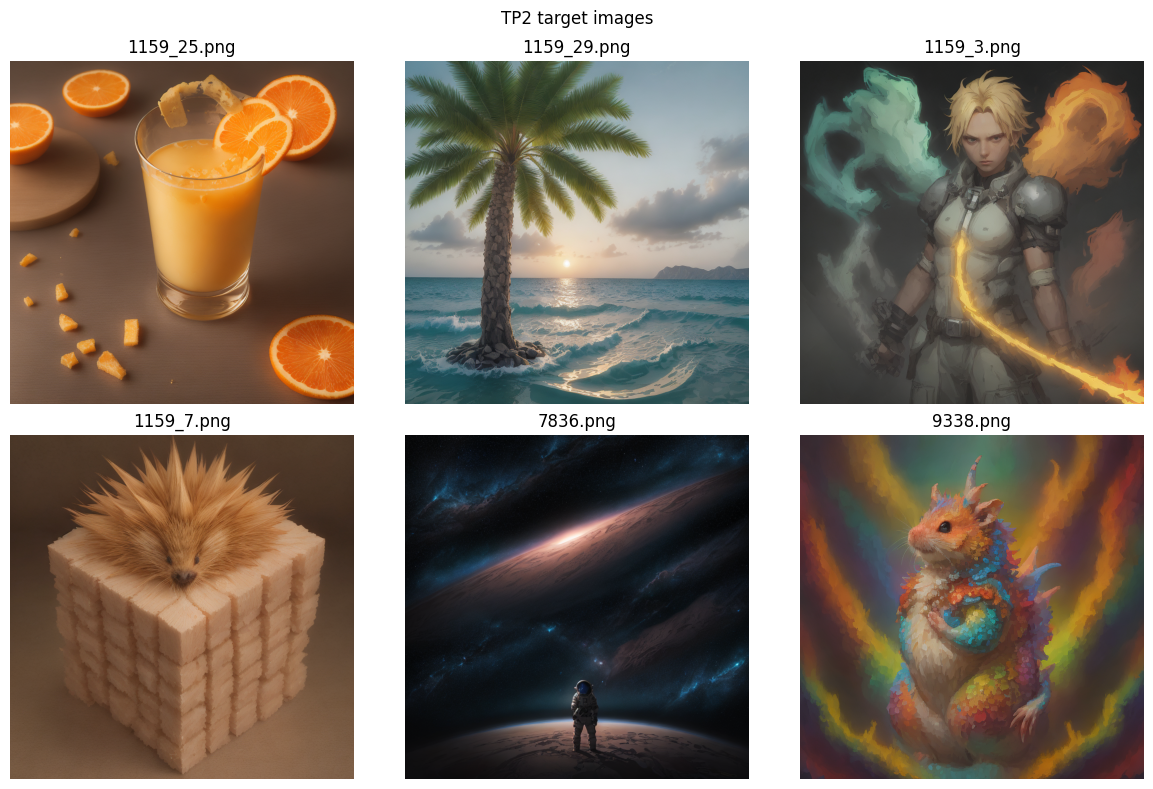

In [5]:
show_images(target_images, cols=3, title="TP2 target images")


## 4. Load the LCM Generator

These are the fixed generation settings used for TP2 targets.

In [ ]:
"""
LCM Config: è il "motore" che genera le immagini
Viene caricata l'IA vera e propria
"""
from dataclasses import dataclass
import torch
from diffusers import DiffusionPipeline

# Definizione delle configurazioni per il modello LCM (Latent Consistency Model)
@dataclass(frozen=True)
class LCMConfig:
    model_id: str = "SimianLuo/LCM_Dreamshaper_v7" # il nome del modello da scaricare
    seed: int = 2026  # fallback only; target filenames define the real render seed
    num_inference_steps: int = 8 # quanti passaggi fa l'IA per generare l'immagine (più alto = più dettagli, ma più tempo)
    guidance_scale: float = 8.0 #  quanto IA deve essere fedele al prompt (più alto = più fedele, ma più rischio di artefatti)
    lcm_origin_steps: int = 50 # parametro specifico del modello LCM che controlla la coerenza tra l'immagine iniziale e quella finale (più alto = più coerenza, ma più rischio di artefatti)
    width: int = 768 # Larghezza immagine in pixel
    height: int = 768 # Altezza immagine in pixel

"""
Nota importante: num_inference_steps: 8 è un valore molto basso. Normalmente i modelli 
standard ne usano 20-50. Questo perché stai usando un modello LCM (Latent Consistency Model), 
che è ultra-veloce e genera immagini di alta qualità in pochissimi step.
"""


config = LCMConfig()


def default_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = default_device()
print("Using device:", device)

# Caricamento del modello LCM (Latent Consistency Model) specificato nella configurazione
def load_lcm_pipeline(config):
    # Sceglie il formato dei dati: float16 (veloce e leggero) per la GPU, float32 per la CPU
    dtype = torch.float16 if device == "cuda" else torch.float32
    
    # Scarica il modello da internet (Hugging Face) e lo carica in memoria
    pipe = DiffusionPipeline.from_pretrained(
        config.model_id,
        torch_dtype=dtype,
        use_safetensors=True,
    )
    
    # Disabilita il filtro di sicurezza (opzionale, per evitare blocchi inutili)
    if hasattr(pipe, "safety_checker"):
        pipe.safety_checker = None
    pipe.to(device)
    return pipe


pipe = load_lcm_pipeline(config)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## 5. Generate and Save Images

Use `render_prompt_for_target(...)` to render a prompt with the seed encoded in the target filename.

In [ ]:
"""
Generare immagine e salvarla su disco
"""
def render_prompt(prompt, seed, pipe=pipe, config=config):
    
    # Decide dove far girare il generatore di numeri casuali
    generator_device = "cpu" if device == "mps" else device
    
    # Crea un "Generatore" basato sul seed (il seme). 
    # Se usi lo stesso seed e lo stesso prompt, otterrai sempre la stessa immagine.
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    
    # Chiama la 'pipe' (il modello caricato prima) con tutti i parametri necessari per generare l'immagine.
    image = pipe(
        prompt=prompt, # descrizione testuale dell'immagine da generare
        num_inference_steps=config.num_inference_steps, # 8 passaggi
        guidance_scale=config.guidance_scale, # quanto deve essere fedele al prompt
        lcm_origin_steps=config.lcm_origin_steps, # coerenza tra immagine iniziale e finale
        width=config.width, # larghezza dell'immagine in pixel
        height=config.height, # altezza dell'immagine in pixel
        output_type="pil", # vogliamo l'immagine come oggetto PIL (Python Imaging Library)
        generator=generator, # il generatore basato sul seed
    ).images[0] # prende la prima immagine generata (in questo caso ne viene generata solo una)
    return image

"""
Funzione che serve a legare un immagine generata a un file di riferimento (target).
"""
def render_prompt_for_target(prompt, target_path):
    seed = seed_from_filename(target_path, config.seed)
    return render_prompt(prompt, seed=seed)

# Funzione che salva l'immagine generata in una cartella specifica, organizzata per target e prompt index
def save_generated_image(image, run_dir, target_path, prompt_index=1):
    target_dir = Path(run_dir) / safe_stem(target_path)
    target_dir.mkdir(parents=True, exist_ok=True)
    path = target_dir / f"candidate_{prompt_index:03d}.png"
    image.save(path)
    return path


## 6. Minimal Example

Change `example_prompt` and `target_path` to test your own prompts.

  0%|          | 0/8 [00:00<?, ?it/s]

Target: tp2-chosen/1159_25.png
Seed: 1159
Prompt: orange juice
Saved generated image: /content/drive/MyDrive/GENAI_TP2/outputs/20260513-152156_starter_example/1159_25/candidate_001.png


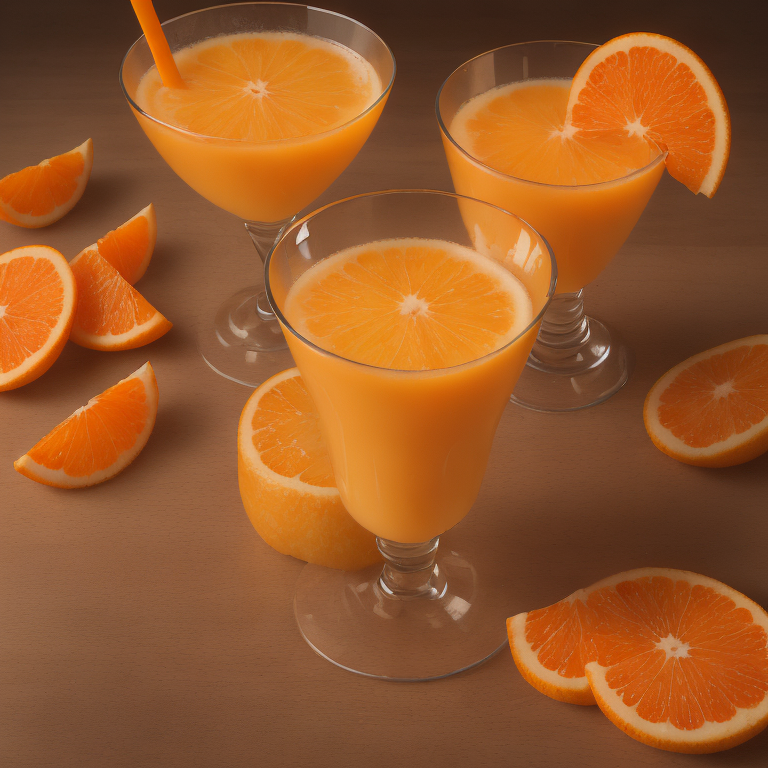

In [15]:
# preparazione della cartella di sessione
run_dir = create_run_dir(identity="starter_example")

# selezione dell'immagine target specifica e definizione del prompt da usare per generare l'immagine
# Qui il codice sta cercando tra tutte le immagini che hai caricato (quelle dello zip) 
# una specifica che si chiama 1159_25.png.
target_path = next(path for path in target_images if Path(path).name == "1159_25.png")

# testo che IA deve trasformare in immagine
example_prompt = "orange juice"

# generazione dell'immagine a partire dal prompt e salvataggio su disco
generated = render_prompt_for_target(example_prompt, target_path)
saved_path = save_generated_image(generated, run_dir, target_path, prompt_index=1)

print("Target:", target_path)
print("Seed:", seed_from_filename(target_path))
print("Prompt:", example_prompt)
print("Saved generated image:", saved_path)

display(generated)


## 7. Batch Template for Student Prompts

Fill `candidate_prompts` with your recovered prompts. The keys must be target filenames.

In [23]:
"""
Processo di produzione di massa. Mentre prima si faceva il test su una sola immagine, 
qui stiamo impostando un sistema per generare automaticamente immagini per più target e più prompt, organizzando tutto in cartelle e salvando i risultati in un file CSV/JSON.
"""

# Definizione dei prompt
# Viene creato un dizionario.
# - chiave: immagine target (nome file)
# - valore: lista di prompt da usare per generare immagini a partire da quel target
candidate_prompts = {
    "1159_25.png": [
        "Orange Juice",
        "A refreshing glass of orange juice with ice cubes and a slice of orange on the rim",
        "A vibrant still life of a glass of orange juice, with condensation on the outside and a bright orange slice garnish, set against a sunny background",
    ],
}

# inizializzazione della sessione
"""
==> run_dir: Crea una nuova cartella (es. outputs/run_002_student_prompts) 
per separare questo lavoro dai test precedenti.

==> rows: Una lista vuota che useremo come "diario di bordo" per segnare tutto quello che succede 
(quale prompt è stato usato, quale seed, dove è stata salvata l'immagine).
"""
run_dir = create_run_dir(identity="student_prompts")
rows = []

# mappatura delle immagini target per nome, per poterle associare facilmente ai prompt
"""
Questa è una dictionary comprehension. Crea un indice veloce per trovare il percorso completo di 
un'immagine partendo solo dal suo nome (es: da "1159_25.png" ottiene "/content/drive/.../1159_25.png").
"""
target_by_name = {Path(path).name: path for path in target_images}

# CICLO DI GENERAZIONE: per ogni immagine target e per ogni prompt associato, genera un'immagine, salvala su disco e registra tutto nel "diario di bordo" (rows)
for image_name, prompts in candidate_prompts.items():
    # Il codice cicla su ogni immagine che hai messo nel dizionario candidate_prompts.
    # Se immagine non esiste tra quelle caricate, stampa un messaggio di avviso e salta alla prossima.
    target_path = target_by_name.get(image_name)
    if target_path is None:
        print("Skipping unknown target:", image_name)
        continue
    # estrae il seed dal nome del file target (o usa il seed di default)
    seed = seed_from_filename(target_path, config.seed)
    
    # ciclo interno per i prompt
    # enumerate serve a tenere traccia di quale numero di prompt stiamo usando (1, 2, 3, ...)
    for index, prompt in enumerate(prompts, start=1):

        generated = render_prompt(prompt, seed=seed)
        
        # carica immagine target per il confronto
        # CARICA L'IMMAGINE TARGET ORIGINALE per il confronto
        target_image_pil = Image.open(target_path).convert("RGB")

        # calcola le metriche 
        metrics = evaluator.calculate_metrics(target_image_pil, generated)
        
        image_path = save_generated_image(generated, run_dir, target_path, prompt_index=index)
        rows.append({
            "target": str(target_path),
            "target_name": image_name,
            "render_seed": seed,
            "candidate_index": index,
            "prompt": prompt,
            "clip_sim": metrics["clip_similarity"],  # Obiettivo: MAX
            "lpips": metrics["lpips_distance"],      # Obiettivo: MIN
            "mse": metrics["pixel_mse"],             # Obiettivo: MIN
            "render": str(image_path),
        })

write_csv(run_dir / "generated_prompts.csv", rows)
(run_dir / "generated_prompts.json").write_text(json.dumps(rows, indent=2, ensure_ascii=False))
print("Saved run to:", run_dir)
print("Generated", len(rows), "image(s)")


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Saved run to: /content/drive/MyDrive/GENAI_TP2/outputs/20260513-154534_student_prompts
Generated 3 image(s)


## 8. View Generated Outputs

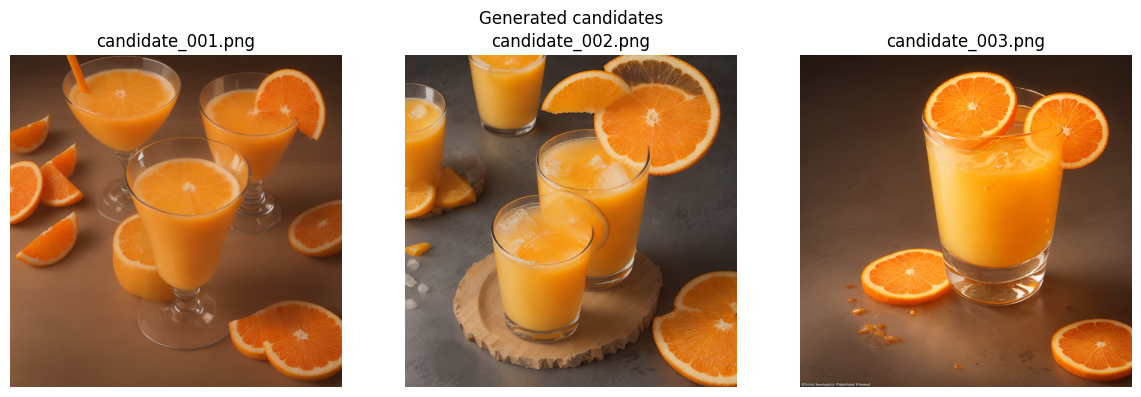

In [19]:
generated_paths = [row["render"] for row in rows]
show_images(generated_paths, cols=3, title="Generated candidates")


## 9. What To Do Next?

Read the full project statement in `GenAI-TP2.pdf` before starting the actual work. This notebook only gives the basic infrastructure for loading targets, controlling seeds, rendering prompts with the fixed LCM setup, and saving outputs.

For the project itself, you still need to design your own method for choosing candidate prompts, run it for every target image, keep the three best prompts per target, save the corresponding generated images, and report the results according to the evaluation protocol in the statement.

In addition to the approach used to obtain good prompts, you must also handle evaluation carefully. The mandatory metrics are:

- CLIP image-image similarity between the target image and the generated image;
- LPIPS perceptual distance between the target image and the generated image;
- Pixel MSE

The report should include the top-3 prompts and generated images for each target, plus the metric values used to justify the ranking.


### Obiettivo finale

Il tuo compito è un'operazione di **"Prompt Inversion"**. Hai 6 immagini "target" (generate dal professore con un'IA e un seme specifico). Tu devi trovare, per ogni immagine, i 3 migliori prompt (descrizioni testuali) che, se dati in pasto alla stessa IA con lo stesso seme, producano un'immagine il più simile possibile all'originale.

### Metrics Evaluation

In [22]:
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import numpy as np
import clip
import lpips

class MetricEvaluator:
    def __init__(self, device="cuda"):
        self.device = device
        # 1. Carica CLIP
        self.clip_model, self.clip_preprocess = clip.load("ViT-B/32", device=device)
        
        # 2. Carica LPIPS (usa vgg come backbone)
        self.lpips_fn = lpips.LPIPS(net='vgg').to(device)
        
        # 3. Trasformazione per MSE e LPIPS (le immagini devono essere tensori)
        self.to_tensor = T.ToTensor()

    def calculate_metrics(self, target_img: Image.Image, generated_img: Image.Image):
        """
        Calcola CLIP Similarity, LPIPS e MSE tra due immagini.
        """
        # Assicuriamoci che siano della stessa dimensione
        if target_img.size != generated_img.size:
            generated_img = generated_img.resize(target_img.size)

        # --- CLIP Similarity (Più alto è, meglio è: 0 a 1) ---
        img1_clip = self.clip_preprocess(target_img).unsqueeze(0).to(self.device)
        img2_clip = self.clip_preprocess(generated_img).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            feat1 = self.clip_model.encode_image(img1_clip)
            feat2 = self.clip_model.encode_image(img2_clip)
            # Normalizzazione e prodotto scalare (Cosenine Similarity)
            feat1 /= feat1.norm(dim=-1, keepdim=True)
            feat2 /= feat2.norm(dim=-1, keepdim=True)
            clip_sim = (feat1 * feat2).sum().item()

        # --- LPIPS (Più basso è, meglio è: 0 = identiche) ---
        # LPIPS vuole i pixel nel range [-1, 1]
        img1_lp = (self.to_tensor(target_img).unsqueeze(0).to(self.device) * 2) - 1
        img2_lp = (self.to_tensor(generated_img).unsqueeze(0).to(self.device) * 2) - 1
        
        with torch.no_grad():
            lpips_dist = self.lpips_fn(img1_lp, img2_lp).item()

        # --- MSE (Più basso è, meglio è: 0 = identiche) ---
        img1_mse = self.to_tensor(target_img).to(self.device)
        img2_mse = self.to_tensor(generated_img).to(self.device)
        mse_dist = F.mse_loss(img1_mse, img2_mse).item()

        return {
            "clip_similarity": clip_sim,
            "lpips_distance": lpips_dist,
            "pixel_mse": mse_dist
        }

# Inizializziamo l'evaluator
evaluator = MetricEvaluator(device=device)

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 65.1MiB/s]


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 82.6MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


### Methods for choose the candidate prompts

In [24]:
from transformers import BlipProcessor, BlipForConditionalGeneration

# Carica il modello di captioning
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

def generate_initial_caption(image_path):
    raw_image = Image.open(image_path).convert('RGB')
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = caption_model.generate(**inputs)
    return processor.decode(out[0], skip_special_tokens=True)

# Testiamolo sulla prima immagine
print(generate_initial_caption(target_images[0]))

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1590: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


a glass of orange juice with a slice of orange


In [27]:
import json

# 1. Lista di "stili" per arricchire i prompt automaticamente
ART_STYLES = [
    "hyperrealistic, cinematic lighting, 8k, highly detailed",
    "digital art, vibrant colors, intricate details, trending on artstation",
    "oil painting style, masterpiece, brush strokes, soft lighting",
    "macro photography, sharp focus, studio background, professional",
    "dreamy atmosphere, soft bokeh, ethereal, fantasy style"
]

def automate_inversion(image_name, num_variants=5):
    target_path = target_by_name[image_name]
    target_img_pil = Image.open(target_path).convert("RGB")
    seed = seed_from_filename(target_path)
    
    # STEP 1: Caption automatica
    base_caption = generate_initial_caption(target_path)
    print(f"\n> Analizzando {image_name}")
    print(f"> Caption base trovata: '{base_caption}'")
    
    # STEP 2: Generazione varianti
    prompts_to_test = [base_caption] # Iniziamo con quella base
    for style in ART_STYLES[:num_variants-1]:
        prompts_to_test.append(f"{base_caption}, {style}")
    
    results = []
    
    # STEP 3: Loop di rendering e valutazione
    for i, prompt in enumerate(prompts_to_test):
        gen_img = render_prompt(prompt, seed=seed)
        m = evaluator.calculate_metrics(target_img_pil, gen_img)
        
        results.append({
            "target_name": image_name,
            "prompt": prompt,
            "clip": m["clip_similarity"],
            "lpips": m["lpips_distance"],
            "mse": m["pixel_mse"]
        })
        print(f"  [Prompt {i+1}/{len(prompts_to_test)}] LPIPS: {m['lpips_distance']:.4f}")

    # STEP 4: Selezione dei Top 3 (basata su LPIPS)
    top_3 = sorted(results, key=lambda x: x["lpips"])[:3]
    return top_3

# --- ESECUZIONE AUTOMATICA SU TUTTI I TARGET ---
all_final_results = {}

# Sostituisci con i nomi reali dei tuoi file se diversi
targets_to_process = ["0808_25.png", "1159_25.png", "1337_25.png", "3456_25.png", "5432_25.png", "9876_25.png"]

for target in targets_to_process:
    if target in target_by_name:
        all_final_results[target] = automate_inversion(target)

print("\n\n✅ PROCESSO COMPLETATO!")

print("\n" + "="*50)
print("📊 REPORT FINALE: I MIGLIORI PROMPT PER OGNI TARGET")
print("="*50)

for target_name, top_prompts in all_final_results.items():
    # Il primo della lista top_prompts è il migliore (LPIPS più basso)
    migliore = top_prompts[0]
    
    print(f"\n🎯 TARGET: {target_name}")
    print(f"🥇 MIGLIOR PROMPT: {migliore['prompt']}")
    print(f"📉 LPIPS (distanza minima): {migliore['lpips']:.4f}")
    print(f"🔗 CLIP Similarity: {migliore['clip']:.4f}")
    print(f"🔲 MSE: {migliore['mse']:.6f}")
    print("-" * 20)


> Analizzando 1159_25.png
> Caption base trovata: 'a glass of orange juice with a slice of orange'


  0%|          | 0/8 [00:00<?, ?it/s]

  [Prompt 1/5] LPIPS: 0.5540


  0%|          | 0/8 [00:00<?, ?it/s]

  [Prompt 2/5] LPIPS: 0.5571


...

  [Prompt 3/5] LPIPS: 0.5911


  0%|          | 0/8 [00:00<?, ?it/s]

  [Prompt 4/5] LPIPS: 0.5601


  0%|          | 0/8 [00:00<?, ?it/s]

  [Prompt 5/5] LPIPS: 0.5788


✅ PROCESSO COMPLETATO!

📊 REPORT FINALE: I MIGLIORI PROMPT PER OGNI TARGET

🎯 TARGET: 1159_25.png
🥇 MIGLIOR PROMPT: a glass of orange juice with a slice of orange
📉 LPIPS (distanza minima): 0.5540
🔗 CLIP Similarity: 0.9321
🔲 MSE: 0.024454
--------------------
